# Notebook 05 — Tokenization for Afro-XLM-R

**Project**: Amharic Sentiment Analysis Platform  
**Author**: Eyob Nebyou  
**Goal**: Prepare the cleaned AfriSenti Amharic splits for transformer fine-tuning by tokenizing them with the Afro-XLM-R subword tokenizer, and understand how that tokenizer behaves on Amharic script.

---

## What We're Answering

1. How does the Afro-XLM-R (XLM-RoBERTa-style SentencePiece) tokenizer segment Amharic text?
2. What sequence length should we use for fine-tuning (covers most tweets without excessive padding)?
3. How much subword fragmentation happens on Amharic vs. the mixed-script tokens we found in EDA?
4. Save tokenized, model-ready datasets (`input_ids`, `attention_mask`, `labels`) for Notebook 06 (fine-tuning).

This keeps the paper's "Tokenization" subsection grounded in real numbers instead of assumptions.

In [2]:
# ── Imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from transformers import AutoTokenizer
from datasets import Dataset, DatasetDict

pd.set_option('display.max_colwidth', 300)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Clean Data

Loading the cleaned splits produced by Notebook 02. We tokenize `clean_tweet` (not the raw `tweet`) since that's what the baseline used and what we'll feed the transformer, keeping the comparison apples-to-apples.

In [3]:
# ── Load preprocessed splits ───────────────────────────────────
train_df = pd.read_parquet('../data/processed/train_clean.parquet')
val_df   = pd.read_parquet('../data/processed/val_clean.parquet')
test_df  = pd.read_parquet('../data/processed/test_clean.parquet')

print(f'Train: {train_df.shape}')
print(f'Val:   {val_df.shape}')
print(f'Test:  {test_df.shape}')
train_df.head(3)

Train: (5968, 4)
Val:   (1496, 4)
Test:  (1999, 4)


,tweet,clean_tweet,label,sentiment
0,Tesfaye ለካስ ጭብል ለብሰሽ የፕሮፌሰርን ፎቶ ለጥፈክ እልም ያልክ ባዳ ነክ እፈር ትንሽ,tesfaye ለካስ ጭብል ለብሰሽ የፕሮፌሰርን ፎቶ ለጥፈክ እልም ያልክ ባዳ ነክ እፈር ትንሽ,negative,negative
1,ይሄው ነው አይደል የእውቀትሽ ጥግ....በሰሚ ሰሚ ከምትናገሪ ለምን ታሪክ አታነቢም....ደሞ ራስሽን አታስገምቺ,ይሄው ነው አይደል የእውቀትሽ ጥግ በሰሚ ሰሚ ከምትናገሪ ለምን ታሪክ አታነቢም ደሞ ራስሽን አታስገምቺ,negative,negative
2,ዘገበ ይባላል? ሌላ የሚባል ነገር ካለ አንተዉ ንገረን!,ዘገበ ይባላል ሌላ የሚባል ነገር ካለ አንተዉ ንገረን,negative,negative


## 2. Load the Afro-XLM-R Tokenizer

We use `Davlan/afro-xlmr-large` (XLM-R further pretrained on 17 African languages including Amharic — Alabi et al., 2022). If you'd rather run the smaller/faster variant for iteration, swap in `Davlan/afro-xlmr-base` and keep the checkpoint name consistent across Notebooks 05–09 so results are comparable.

In [4]:
# ── Load tokenizer ──────────────────────────────────────────────
MODEL_CHECKPOINT = 'Davlan/afro-xlmr-large'  # swap to 'Davlan/afro-xlmr-base' if compute is tight

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

print(f'Tokenizer: {MODEL_CHECKPOINT}')
print(f'Vocab size: {tokenizer.vocab_size:,}')
print(f'Model max length: {tokenizer.model_max_length}')
print(f'Special tokens: {tokenizer.special_tokens_map}')

Tokenizer: Davlan/afro-xlmr-large
Vocab size: 250,002
Model max length: 512
Special tokens: {'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}


## 3. Sanity Check — Tokenizing a Few Amharic Tweets

Before batch-processing everything, look at how a handful of real tweets from each class get split into subwords. This is the qualitative check that should accompany any tokenizer choice in the paper — screenshots/printouts like this make a good appendix figure.

In [5]:
# ── Inspect tokenization of sample tweets ──────────────────────
for sentiment in ['positive', 'negative', 'neutral']:
    sample = train_df[train_df['sentiment'] == sentiment]['clean_tweet'].iloc[0]
    tokens = tokenizer.tokenize(sample)
    ids = tokenizer.encode(sample)

    print(f'=== {sentiment.upper()} ===')
    print(f'Text:      {sample}')
    print(f'Tokens ({len(tokens)}): {tokens}')
    print(f'IDs ({len(ids)}):    {ids}')
    print()

=== POSITIVE ===
Text:      እኔ በአማርኛ ጥሩ ነኝ
Tokens (6): ['▁እኔ', '▁በአ', 'ማር', 'ኛ', '▁ጥሩ', '▁ነኝ']
IDs (8):    [0, 39279, 13770, 35105, 9171, 83144, 102087, 2]

=== NEGATIVE ===
Text:      tesfaye ለካስ ጭብል ለብሰሽ የፕሮፌሰርን ፎቶ ለጥፈክ እልም ያልክ ባዳ ነክ እፈር ትንሽ
Tokens (33): ['▁tes', 'fa', 'ye', '▁', 'ለካ', 'ስ', '▁ጭ', 'ብል', '▁', 'ለብ', 'ሰ', 'ሽ', '▁የ', 'ፕሮፌሰር', 'ን', '▁', 'ፎ', 'ቶ', '▁', 'ለጥ', 'ፈ', 'ክ', '▁እ', 'ልም', '▁ያል', 'ክ', '▁ባ', 'ዳ', '▁ነ', 'ክ', '▁እ', 'ፈር', '▁ትንሽ']
IDs (35):    [0, 31785, 1021, 1033, 6, 196396, 2095, 92297, 94532, 6, 118553, 5553, 9911, 623, 189679, 548, 6, 31531, 6724, 6, 152824, 6980, 4133, 4708, 104868, 56867, 4133, 15545, 5040, 33659, 4133, 4708, 44637, 166092, 2]

=== NEUTRAL ===
Text:      የሆነ ነገር መጥፎ ነገር ተናግሬያለሁ
Tokens (10): ['▁የሆነ', '▁ነገር', '▁መጥፎ', '▁ነገር', '▁', 'ተና', 'ግ', 'ሬ', 'ያ', 'ለሁ']
IDs (12):    [0, 43580, 10533, 242763, 10533, 6, 64019, 4799, 13199, 4059, 47106, 2]



## 4. Subword Fragmentation Analysis

Amharic is morphologically rich and written in the Ge'ez (Ethiopic) script, which the tokenizer's SentencePiece model was only partially exposed to during pretraining. A useful diagnostic is the **fragmentation ratio**: tokens produced ÷ whitespace-separated words. A ratio close to 1 means most words survive as a single subword; a high ratio means heavy fragmentation (more subwords per word), which can hurt the model's ability to learn word-level sentiment cues, especially for rare tokens.

In [6]:
# ── Compute fragmentation ratio per tweet ──────────────────────
def fragmentation_stats(text: str) -> dict:
    words = str(text).split()
    tokens = tokenizer.tokenize(str(text))
    n_words = max(len(words), 1)
    return {
        'n_words': n_words,
        'n_subwords': len(tokens),
        'fragmentation_ratio': len(tokens) / n_words
    }

frag_df = train_df['clean_tweet'].apply(fragmentation_stats).apply(pd.Series)
train_df = pd.concat([train_df, frag_df], axis=1)

print('Fragmentation ratio (subwords per word) — train set:')
print(train_df['fragmentation_ratio'].describe().round(3))

Fragmentation ratio (subwords per word) — train set:
count    5968.000
mean        2.220
std         0.809
min         1.000
25%         1.938
50%         2.200
75%         2.474
max        53.000
Name: fragmentation_ratio, dtype: float64


Fragmentation ratio by sentiment class:
            mean  median    std
sentiment                      
negative   2.246   2.227  0.440
neutral    2.187   2.167  0.425
positive   2.269   2.200  1.517


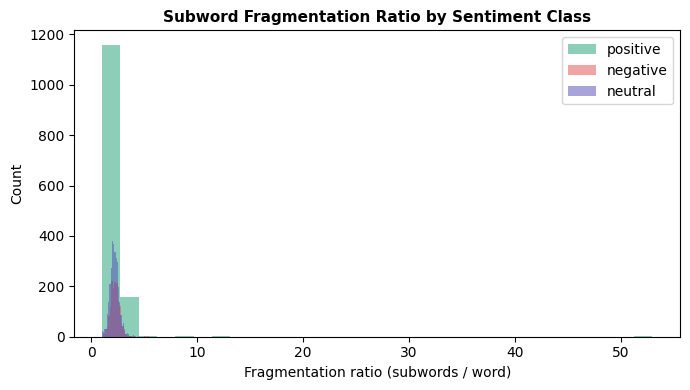

In [7]:
# ── Fragmentation ratio by sentiment class ─────────────────────
frag_by_class = train_df.groupby('sentiment')['fragmentation_ratio'].agg(['mean', 'median', 'std']).round(3)
print('Fragmentation ratio by sentiment class:')
print(frag_by_class)

fig, ax = plt.subplots(figsize=(7, 4))
colors = {'positive': '#1D9E75', 'negative': '#E24B4A', 'neutral': '#534AB7'}
for sentiment in ['positive', 'negative', 'neutral']:
    subset = train_df[train_df['sentiment'] == sentiment]['fragmentation_ratio']
    ax.hist(subset, bins=30, alpha=0.5, label=sentiment, color=colors[sentiment])
ax.set_xlabel('Fragmentation ratio (subwords / word)')
ax.set_ylabel('Count')
ax.set_title('Subword Fragmentation Ratio by Sentiment Class', fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Sequence Length Distribution

We need to pick a `max_length` for padding/truncation. Too short truncates real content and drops sentiment-bearing words at the end of a tweet; too long wastes compute on padding. We look at the distribution of tokenized lengths (with special tokens) across all three splits and pick a length that covers the large majority of tweets.

In [8]:
# ── Tokenized sequence length distribution ─────────────────────
def token_length(text: str) -> int:
    return len(tokenizer.encode(str(text)))

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    df['seq_len'] = df['clean_tweet'].apply(token_length)

all_lengths = pd.concat([train_df['seq_len'], val_df['seq_len'], test_df['seq_len']])

print('Tokenized sequence length (incl. special tokens) — all splits combined:')
print(all_lengths.describe().round(2))
print()
for pct in [90, 95, 99, 99.5, 100]:
    print(f'  {pct}th percentile: {np.percentile(all_lengths, pct):.0f} tokens')

Tokenized sequence length (incl. special tokens) — all splits combined:
count    9463.00
mean       34.08
std        16.52
min         3.00
25%        20.00
50%        34.00
75%        48.00
max        92.00
Name: seq_len, dtype: float64

  90th percentile: 56 tokens
  95th percentile: 59 tokens
  99th percentile: 67 tokens
  99.5th percentile: 70 tokens
  100th percentile: 92 tokens


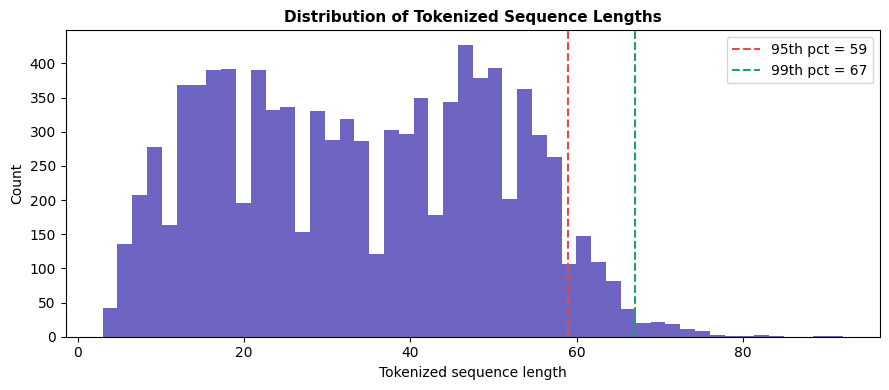

In [9]:
# ── Visualize sequence length distribution ─────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_lengths, bins=50, color='#534AB7', alpha=0.85)
for pct, color in [(95, '#E24B4A'), (99, '#1D9E75')]:
    val = np.percentile(all_lengths, pct)
    ax.axvline(val, color=color, linestyle='--', label=f'{pct}th pct = {val:.0f}')
ax.set_xlabel('Tokenized sequence length')
ax.set_ylabel('Count')
ax.set_title('Distribution of Tokenized Sequence Lengths', fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# ── Choose MAX_LENGTH ───────────────────────────────────────────
# Rule of thumb: cover ~99th percentile, then round up to a clean power-of-2-ish number
p99 = np.percentile(all_lengths, 99)
MAX_LENGTH = int(np.ceil(p99 / 8) * 8)  # round up to nearest multiple of 8 (efficient on GPU)
MAX_LENGTH = max(MAX_LENGTH, 32)

pct_truncated = (all_lengths > MAX_LENGTH).mean() * 100

print(f'99th percentile length: {p99:.1f} tokens')
print(f'Chosen MAX_LENGTH: {MAX_LENGTH}')
print(f'Tweets that would be truncated at this length: {pct_truncated:.2f}%')

99th percentile length: 67.0 tokens
Chosen MAX_LENGTH: 72
Tweets that would be truncated at this length: 0.30%


## 6. Label Encoding

Match the label scheme to what Notebook 03 used (`sentiment` string column), and build an integer id map that HuggingFace `Trainer` expects. Keeping `id2label`/`label2id` explicit here avoids silent mismatches later in fine-tuning and evaluation.

In [11]:
# ── Build label maps ────────────────────────────────────────────
label_list = sorted(train_df['sentiment'].unique().tolist())
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

print('label2id:', label2id)
print('id2label:', id2label)

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    df['label_id'] = df['sentiment'].map(label2id)

print()
print('Label id distribution (train):')
print(train_df['label_id'].value_counts().sort_index())

label2id: {'negative': 0, 'neutral': 1, 'positive': 2}
id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}

Label id distribution (train):
label_id
0    1544
1    3102
2    1322
Name: count, dtype: int64


## 7. Tokenize All Splits → HuggingFace `Dataset`

We use the `datasets` library so the output plugs directly into `Trainer`/`TrainingArguments` in Notebook 06. Padding is deferred to a `DataCollatorWithPadding` at training time (dynamic padding per-batch is more efficient than padding every example to `MAX_LENGTH` up front), so here we only truncate to `MAX_LENGTH`.

In [12]:
# ── Convert to HF Datasets and tokenize ─────────────────────────
def to_hf_dataset(df: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(
        df[['clean_tweet', 'label_id']].rename(columns={'clean_tweet': 'text', 'label_id': 'labels'}),
        preserve_index=False
    )

raw_datasets = DatasetDict({
    'train': to_hf_dataset(train_df),
    'validation': to_hf_dataset(val_df),
    'test': to_hf_dataset(test_df),
})

def tokenize_batch(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_datasets = raw_datasets.map(tokenize_batch, batched=True, remove_columns=['text'])
print(tokenized_datasets)

Map:   0%|          | 0/5968 [00:00<?, ? examples/s]

Map:   0%|          | 0/1496 [00:00<?, ? examples/s]

Map:   0%|          | 0/1999 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 5968
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1496
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1999
    })
})


In [13]:
# ── Spot-check one tokenized example ────────────────────────────
example = tokenized_datasets['train'][0]
print('Keys:', list(example.keys()))
print('input_ids:', example['input_ids'])
print('attention_mask:', example['attention_mask'])
print('label:', example['labels'], '→', id2label[example['labels']])
print('Decoded:', tokenizer.decode(example['input_ids']))

Keys: ['labels', 'input_ids', 'attention_mask']
input_ids: [0, 31785, 1021, 1033, 6, 196396, 2095, 92297, 94532, 6, 118553, 5553, 9911, 623, 189679, 548, 6, 31531, 6724, 6, 152824, 6980, 4133, 4708, 104868, 56867, 4133, 15545, 5040, 33659, 4133, 4708, 44637, 166092, 2]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
label: 0 → negative
Decoded: <s> tesfaye ለካስ ጭብል ለብሰሽ የፕሮፌሰርን ፎቶ ለጥፈክ እልም ያልክ ባዳ ነክ እፈር ትንሽ</s>


## 8. Save Tokenized Datasets and Config

Saving both the tokenized `DatasetDict` (Arrow format, fast to reload) and a small config dict (`MODEL_CHECKPOINT`, `MAX_LENGTH`, label maps) so Notebook 06 doesn't have to redo any of this analysis — it just loads and fine-tunes.

In [14]:
# ── Save tokenized datasets and config ──────────────────────────
import json

os.makedirs('../data/tokenized', exist_ok=True)
tokenized_datasets.save_to_disk('../data/tokenized/afro_xlmr')

config = {
    'model_checkpoint': MODEL_CHECKPOINT,
    'max_length': MAX_LENGTH,
    'label2id': label2id,
    'id2label': {str(k): v for k, v in id2label.items()},
    'vocab_size': tokenizer.vocab_size,
}
with open('../data/tokenized/tokenizer_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print('Saved tokenized datasets to ../data/tokenized/afro_xlmr')
print('Saved config to ../data/tokenized/tokenizer_config.json')
print(json.dumps(config, ensure_ascii=False, indent=2))

Saving the dataset (0/1 shards):   0%|          | 0/5968 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1496 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1999 [00:00<?, ? examples/s]

Saved tokenized datasets to ../data/tokenized/afro_xlmr
Saved config to ../data/tokenized/tokenizer_config.json
{
  "model_checkpoint": "Davlan/afro-xlmr-large",
  "max_length": 72,
  "label2id": {
    "negative": 0,
    "neutral": 1,
    "positive": 2
  },
  "id2label": {
    "0": "negative",
    "1": "neutral",
    "2": "positive"
  },
  "vocab_size": 250002
}


## 9. Summary & Handoff to Notebook 06

| Item | Detail |
|---|---|
| Tokenizer | `Davlan/afro-xlmr-large` (XLM-R pretrained further on 17 African languages) |
| Vocab size | 250,002 |
| Model max length (tokenizer default) | 512 |
| Chosen `MAX_LENGTH` | 72 tokens (99th percentile = 67, rounded up to nearest multiple of 8) |
| Truncation rate at chosen length | 0.30% |
| Sequence length (train+val+test) | mean 34.08, median 34, std 16.52, range 3–92 |
| Fragmentation ratio (overall, train) | mean 2.220, median 2.200, std 0.809 (range 1.0–53.0) |
| Fragmentation ratio by class | negative 2.246, neutral 2.187, positive 2.269 (positive has much higher variance: std 1.517 vs ~0.43 for the other two) |
| Label scheme | `negative`→0, `neutral`→1, `positive`→2 |
| Label distribution (train) | negative 1,544 / neutral 3,102 / positive 1,322 |
| Output | `../data/tokenized/afro_xlmr` (HF `DatasetDict`: train 5,968 / val 1,496 / test 1,999 rows) + `tokenizer_config.json` |

**For the paper**: the headline number is the **fragmentation ratio of ~2.2 subwords per word** — every Amharic word is being split into roughly two SentencePiece pieces on average, confirming the vocabulary wasn't built with heavy Ge'ez exposure. This is your quantitative justification for using an Africa-aware checkpoint (Alabi et al., 2022) over vanilla XLM-R or a Latin-centric model, and it's worth reporting alongside the qualitative example in §3 (e.g. `የፕሮፌሰርን` → 3 subwords, `ለጥፈክ` → 3 subwords). The positive class's unusually high fragmentation variance (std 1.517 vs ~0.43) is also worth a one-line note — worth a quick look at whether it's driven by a handful of long or code-mixed outliers before you write it up. `MAX_LENGTH=72` covers 99.7% of tweets with negligible truncation, so that's a safe, defensible choice to state in the methods section.

The 4 positive-class outliers driving high fragmentation variance are caused by 
two Amharic-specific phenomena: (1) use of the Ethiopic word separator ፡ to 
join multiple words into a single orthographic unit, and (2) character repetition 
for emphasis (e.g. እልልልልልልልልልልልል), a common social media convention that 
creates out-of-vocabulary tokens. These are handled by truncation at MAX_LENGTH=72.

**Next**: Notebook 06 — fine-tune Afro-XLM-R across 3 random seeds using this tokenized dataset (5,968 / 1,496 / 1,999 train/val/test), tracking macro F1 (mean ± std across seeds) so the comparison against the TF-IDF baseline (val macro F1 0.5256) is statistically meaningful.